# Granizos más grandes en un clima más cálido

**Para finales del siglo XXI, los granizos de 30 mm o más podrían ser entre 38% y 52% más frecuentes.** Eso es el rango que un modelo global de trayectorias de granizo proyecta — y el daño económico total subiría entre 36% y 42%.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

> **Paper:** *Rising global hail damage potential in a warming world* — Nature (2026)
> **DOI:** [10.1038/s41586-026-10543-2](https://doi.org/10.1038/s41586-026-10543-2)
>
> [![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-27-granizo-global-clima/notebook.ipynb)

## Qué hicieron

El equipo corrió un modelo semi-3D que sigue cada granizo desde que se forma hasta que cae, alimentado por cinco corridas del modelo climático EC-Earth3 (uno de los modelos de referencia en Europa), bajo tres escenarios de emisiones de gases de efecto invernadero para finales de siglo (SSP245, 370 y 585 — de moderado a muy alto). Validaron contra observaciones reales en Estados Unidos (9.462 reportes agregados, 2010-2020) y China (8.818 reportes, 1986-1999) antes de proyectar al futuro.

Aquí abrimos las cuatro tablas que el paper deja accesibles: primero comparamos el modelo contra observaciones reales, y después vamos a lo que importa — cuánto sube el daño proyectado.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_GRANDE_MM = 30        # Diámetro a partir del cual el granizo es "grande" (paper)
COLOR_OBS = '#2563EB'        # Azul CaM — observaciones reales
COLOR_SIM = '#DC2626'        # Rojo — simulaciones del modelo
COLOR_PROYECCION = '#7C3AED' # Violeta — proyecciones futuras
COLOR_REFERENCIA = '#D97706' # Ámbar — umbrales y referencias
FUENTE = 'Fuente: Wang et al. (2026), Nature | Datos: Figshare 30103471'

# ──────────────────────────────────────────────────────────────
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Estilo CaM (local primero, fallback a GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file
        )
plt.style.use(style_file)

# Carga de los 4 CSVs
us_hist = pd.read_csv('datos/us_diam_histograma_2010_2020.csv')
china   = pd.read_csv('datos/china_obs_anual_1966_1999.csv')
entornos = pd.read_csv('datos/entornos_convectivos_hist_2014_2021.csv')
proy    = pd.read_csv('datos/proyecciones_paper_late21c.csv')

print(f'US histograma     : {len(us_hist)} bins de 5 mm  ({us_hist.obs_eventos.sum():,} eventos obs)')
print(f'China anual       : {len(china)} años           ({china.n_eventos.sum():,} eventos obs)')
print(f'Entornos globales : {len(entornos):,} entornos convectivos sampleados (2014-2021)')
print(f'Proyecciones      : {len(proy)} métricas del paper para finales del s.XXI')

US histograma     : 20 bins de 5 mm  (9,462 eventos obs)
China anual       : 28 años           (11,222 eventos obs)
Entornos globales : 3,996 entornos convectivos sampleados (2014-2021)
Proyecciones      : 6 métricas del paper para finales del s.XXI


## Aquí está.

Estos son los 3.996 entornos atmosféricos que el modelo usa como base histórica, coloreados por la energía disponible para tormentas — los meteorólogos la llaman MUCAPE y se mide en julios por kilogramo.

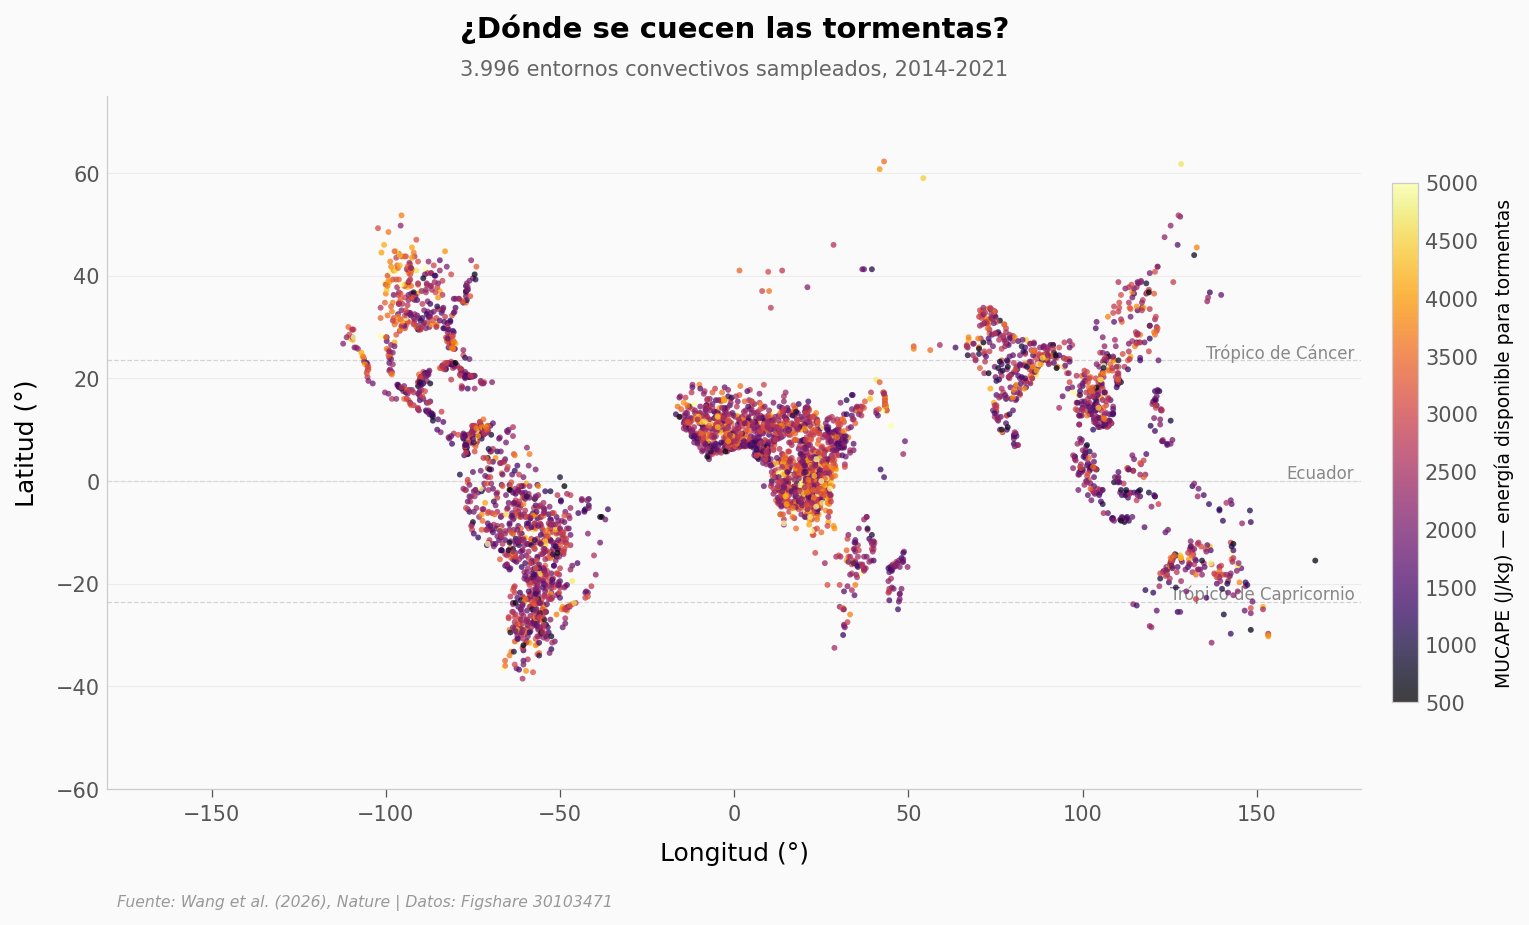

In [2]:
fig, ax = plt.subplots(figsize=(13, 6))

# Centrar el mapa en el Atlántico: lon 0-360 → -180 a 180
lons_centered = np.where(entornos.lon > 180, entornos.lon - 360, entornos.lon)

sc = ax.scatter(
    lons_centered, entornos.lat,
    c=entornos.mucape_jkg, cmap='inferno',
    s=8, alpha=0.75, vmin=500, vmax=5000,
    edgecolors='none', zorder=5
)

# Líneas de referencia geográficas (ecuador + trópicos)
for y in [-23.5, 0, 23.5]:
    ax.axhline(y=y, color='#BBBBBB', linewidth=0.6, linestyle='--', alpha=0.6, zorder=1)

ax.text(178, 0.5, 'Ecuador', fontsize=8, color='#888888', ha='right')
ax.text(178, 24, 'Trópico de Cáncer', fontsize=8, color='#888888', ha='right')
ax.text(178, -23, 'Trópico de Capricornio', fontsize=8, color='#888888', ha='right')

# Colorbar
cbar = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label('MUCAPE (J/kg) — energía disponible para tormentas', fontsize=9)

ax.set_xlim(-180, 180)
ax.set_ylim(-60, 75)
ax.set_xlabel('Longitud (°)')
ax.set_ylabel('Latitud (°)')
ax.set_title('¿Dónde se cuecen las tormentas?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '3.996 entornos convectivos sampleados, 2014-2021',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_entornos_globales.png', dpi=200, bbox_inches='tight')
plt.show()

Lo que llama la atención: el muestreo se concentra cerca del ecuador y en los trópicos. Esto no significa que sea donde caen los granizos grandes — el equipo eligió este patrón porque allí abundan los entornos convectivos diversos que el modelo necesita calibrar. Las tormentas con granizos grandes viven más al norte, sobre todo en latitudes medias-altas, y eso aparecerá en las proyecciones.

Antes de mirar el futuro, primero hay que comprobar que el modelo se parece a la realidad.

## ¿Le creemos al modelo?

La prueba más directa: comparar las distribuciones de tamaño de granizo simuladas contra observaciones de campo. Empezamos por Estados Unidos, donde la red de reportes es densa y consistente (2010-2020).

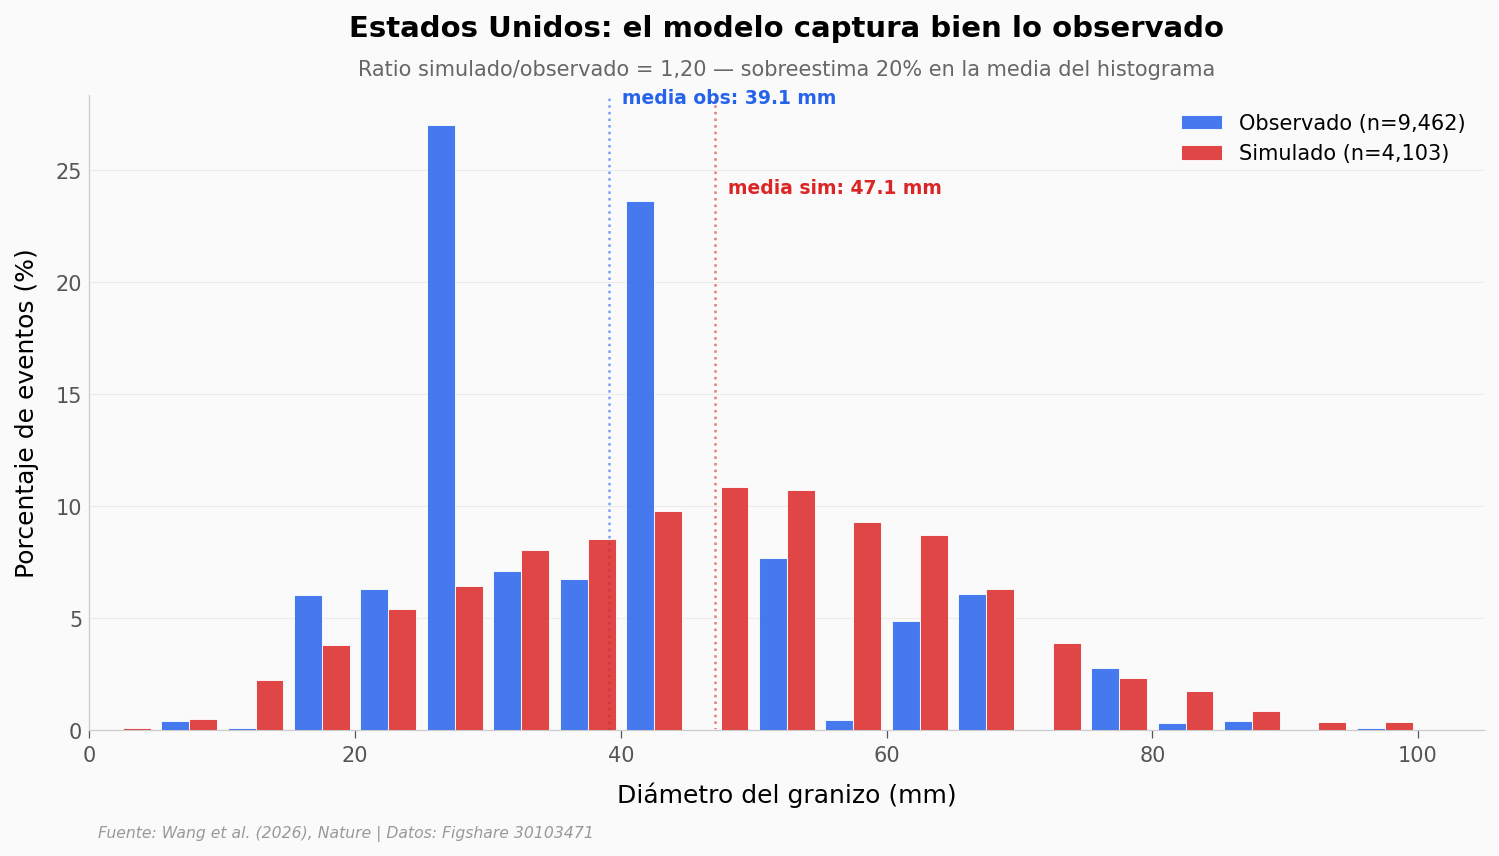

In [3]:
fig, ax = plt.subplots(figsize=(12, 5.5))

# Bins (centro de cada bin de 5 mm)
bin_centers = (us_hist.bin_min_mm + us_hist.bin_max_mm) / 2
width = 4.2  # un poco menor que 5 para dejar gap visual

# Normalizar a porcentaje (mejor comparación visual: obs y sim tienen N distinto)
obs_pct = us_hist.obs_eventos / us_hist.obs_eventos.sum() * 100
sim_pct = us_hist.sim_eventos / us_hist.sim_eventos.sum() * 100

ax.bar(bin_centers - width/4, obs_pct, width=width/2,
       color=COLOR_OBS, alpha=0.85, edgecolor='white', linewidth=0.5,
       label=f'Observado (n={us_hist.obs_eventos.sum():,})', zorder=5)
ax.bar(bin_centers + width/4, sim_pct, width=width/2,
       color=COLOR_SIM, alpha=0.85, edgecolor='white', linewidth=0.5,
       label=f'Simulado (n={us_hist.sim_eventos.sum():,})', zorder=5)

# Anotaciones de medias
# Recalculado desde el histograma (bin centers ponderados por eventos)
obs_mean_mm = round((bin_centers * us_hist.obs_eventos).sum() / us_hist.obs_eventos.sum(), 1)
sim_mean_mm = round((bin_centers * us_hist.sim_eventos).sum() / us_hist.sim_eventos.sum(), 1)
ax.axvline(x=obs_mean_mm, color=COLOR_OBS, linewidth=1.2, linestyle=':', alpha=0.6, zorder=2)
ax.axvline(x=sim_mean_mm, color=COLOR_SIM, linewidth=1.2, linestyle=':', alpha=0.6, zorder=2)
ax.text(obs_mean_mm, ax.get_ylim()[1]*0.92 if False else 28, f'  media obs: {obs_mean_mm} mm',
        fontsize=9, color=COLOR_OBS, fontweight='bold')
ax.text(sim_mean_mm, 24, f'  media sim: {sim_mean_mm} mm',
        fontsize=9, color=COLOR_SIM, fontweight='bold')

ax.set_xlabel('Diámetro del granizo (mm)')
ax.set_ylabel('Porcentaje de eventos (%)')
ax.set_title('Estados Unidos: el modelo captura bien lo observado',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Ratio simulado/observado = 1,20 — sobreestima 20% en la media del histograma',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.set_xlim(0, 105)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_validacion_us.png', dpi=200, bbox_inches='tight')
plt.show()

En Estados Unidos el modelo sobreestima apenas 20% en la media del histograma — una correspondencia muy buena en climatología de tormentas. ¿Pasa lo mismo en China?

No exactamente. Y aquí el dato cuenta una historia interesante: a veces el "error" del modelo es en realidad un sesgo de las observaciones.

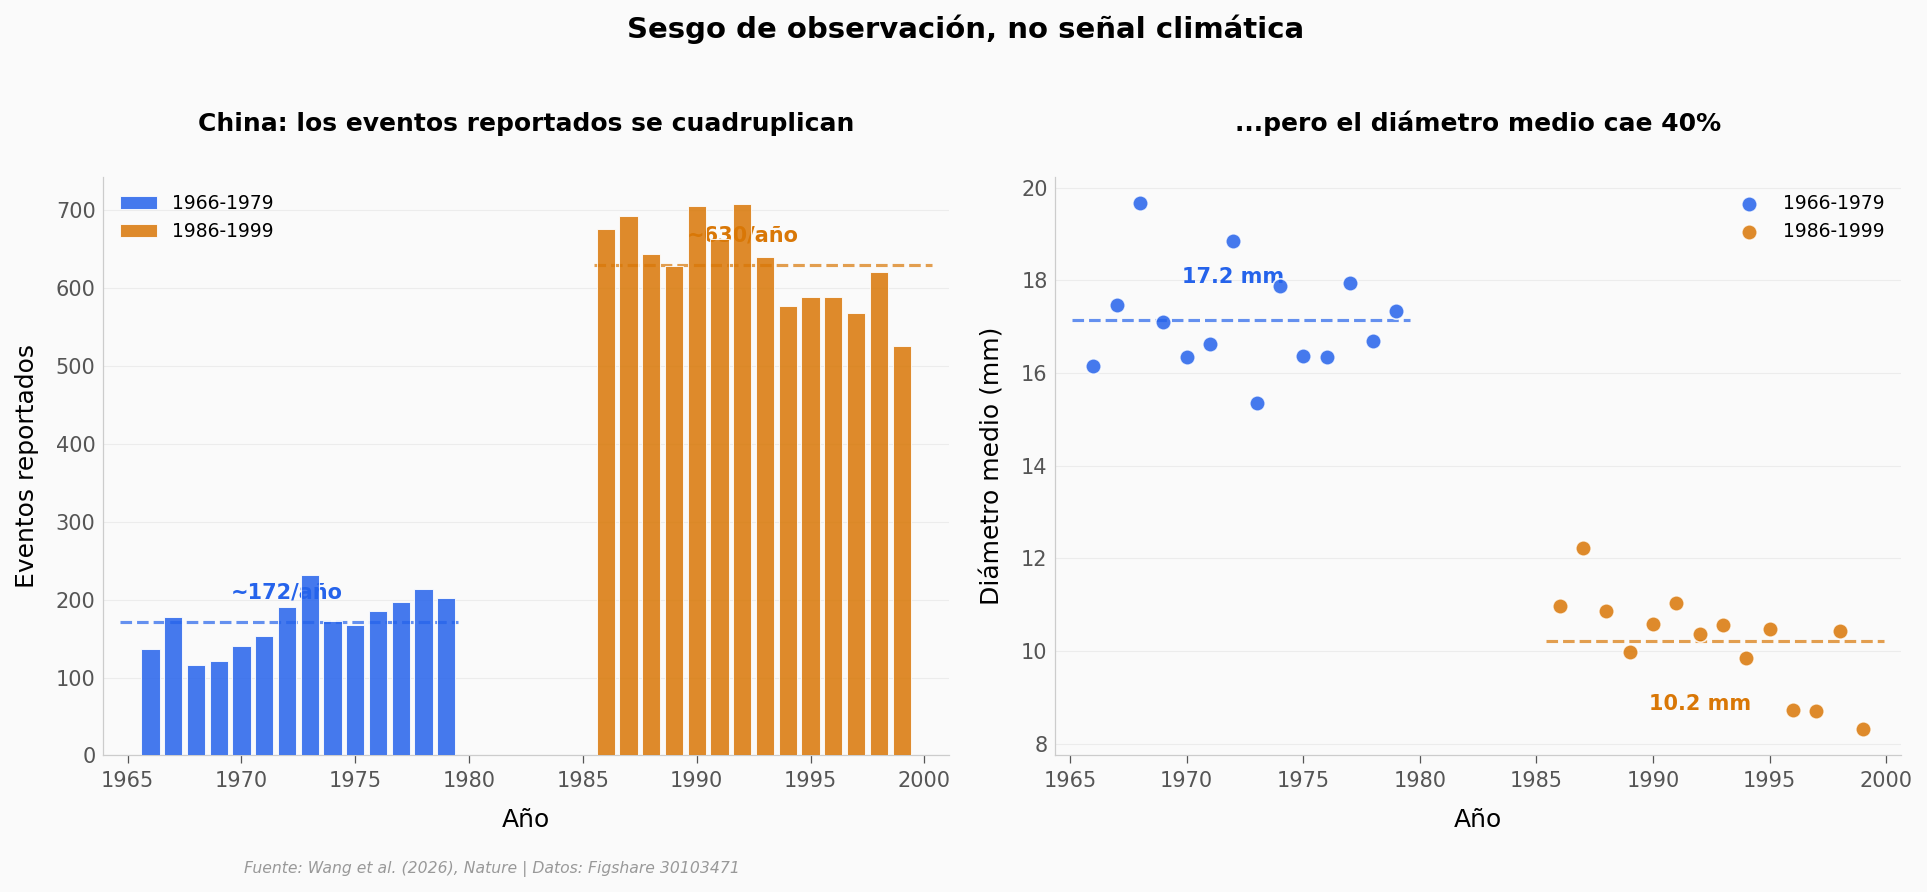

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# Separar las dos décadas (hay un gap 1980-1985)
p1 = china[china.year <= 1979].copy()
p2 = china[china.year >= 1986].copy()

# Panel A: eventos por año
ax1.bar(p1.year, p1.n_eventos, color=COLOR_OBS, alpha=0.85,
        edgecolor='white', linewidth=0.5, label='1966-1979', zorder=5)
ax1.bar(p2.year, p2.n_eventos, color=COLOR_REFERENCIA, alpha=0.85,
        edgecolor='white', linewidth=0.5, label='1986-1999', zorder=5)

p1_mean_n = p1.n_eventos.mean()
p2_mean_n = p2.n_eventos.mean()
ax1.axhline(y=p1_mean_n, xmin=0.02, xmax=0.42,
            color=COLOR_OBS, linewidth=1.5, linestyle='--', alpha=0.7)
ax1.axhline(y=p2_mean_n, xmin=0.58, xmax=0.98,
            color=COLOR_REFERENCIA, linewidth=1.5, linestyle='--', alpha=0.7)

ax1.text(1972, p1_mean_n + 30, f'~{p1_mean_n:.0f}/año',
         fontsize=10, color=COLOR_OBS, fontweight='bold', ha='center')
ax1.text(1992, p2_mean_n + 30, f'~{p2_mean_n:.0f}/año',
         fontsize=10, color=COLOR_REFERENCIA, fontweight='bold', ha='center')

ax1.set_xlabel('Año')
ax1.set_ylabel('Eventos reportados')
ax1.set_title('China: los eventos reportados se cuadruplican',
              fontsize=12, fontweight='bold', pad=22)
ax1.legend(loc='upper left', fontsize=9, framealpha=0.9)

# Panel B: diámetro medio anual
ax2.scatter(p1.year, p1.mean_diam_mm, s=55, color=COLOR_OBS, alpha=0.85,
            edgecolors='white', linewidths=0.8, zorder=5, label='1966-1979')
ax2.scatter(p2.year, p2.mean_diam_mm, s=55, color=COLOR_REFERENCIA, alpha=0.85,
            edgecolors='white', linewidths=0.8, zorder=5, label='1986-1999')

p1_mean_d = p1.mean_diam_mm.mean()
p2_mean_d = p2.mean_diam_mm.mean()
ax2.axhline(y=p1_mean_d, xmin=0.02, xmax=0.42,
            color=COLOR_OBS, linewidth=1.5, linestyle='--', alpha=0.7)
ax2.axhline(y=p2_mean_d, xmin=0.58, xmax=0.98,
            color=COLOR_REFERENCIA, linewidth=1.5, linestyle='--', alpha=0.7)

ax2.text(1972, p1_mean_d + 0.8, f'{p1_mean_d:.1f} mm', fontsize=10,
         color=COLOR_OBS, fontweight='bold', ha='center')
ax2.text(1992, p2_mean_d - 1.5, f'{p2_mean_d:.1f} mm', fontsize=10,
         color=COLOR_REFERENCIA, fontweight='bold', ha='center')

ax2.set_xlabel('Año')
ax2.set_ylabel('Diámetro medio (mm)')
ax2.set_title('...pero el diámetro medio cae 40%',
              fontsize=12, fontweight='bold', pad=22)
ax2.legend(loc='upper right', fontsize=9, framealpha=0.9)

fig.suptitle('Sesgo de observación, no señal climática',
             fontsize=14, fontweight='bold', y=1.02)
fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/03_china_sesgo_obs.png', dpi=200, bbox_inches='tight')
plt.show()

Entre los 70s y los 90s, los reportes de granizo en China casi se cuadruplican (~170 → ~630 por año) y a la vez el diámetro medio cae 40% (17 mm → 10 mm). Eso no es el clima cambiando: es la red de observación densificándose. Cuando hay más estaciones reportando, aparecen granizos más pequeños que antes nadie registraba.

Por eso en China el modelo "sobreestima" en 2,5x (factor reportado por el paper): el modelo no ve los granizos diminutos de 5-8 mm que las observaciones modernas sí capturan. No es error del modelo — es contraste de muestreo.

Con la validación cuadrada, viene la pregunta que importa.

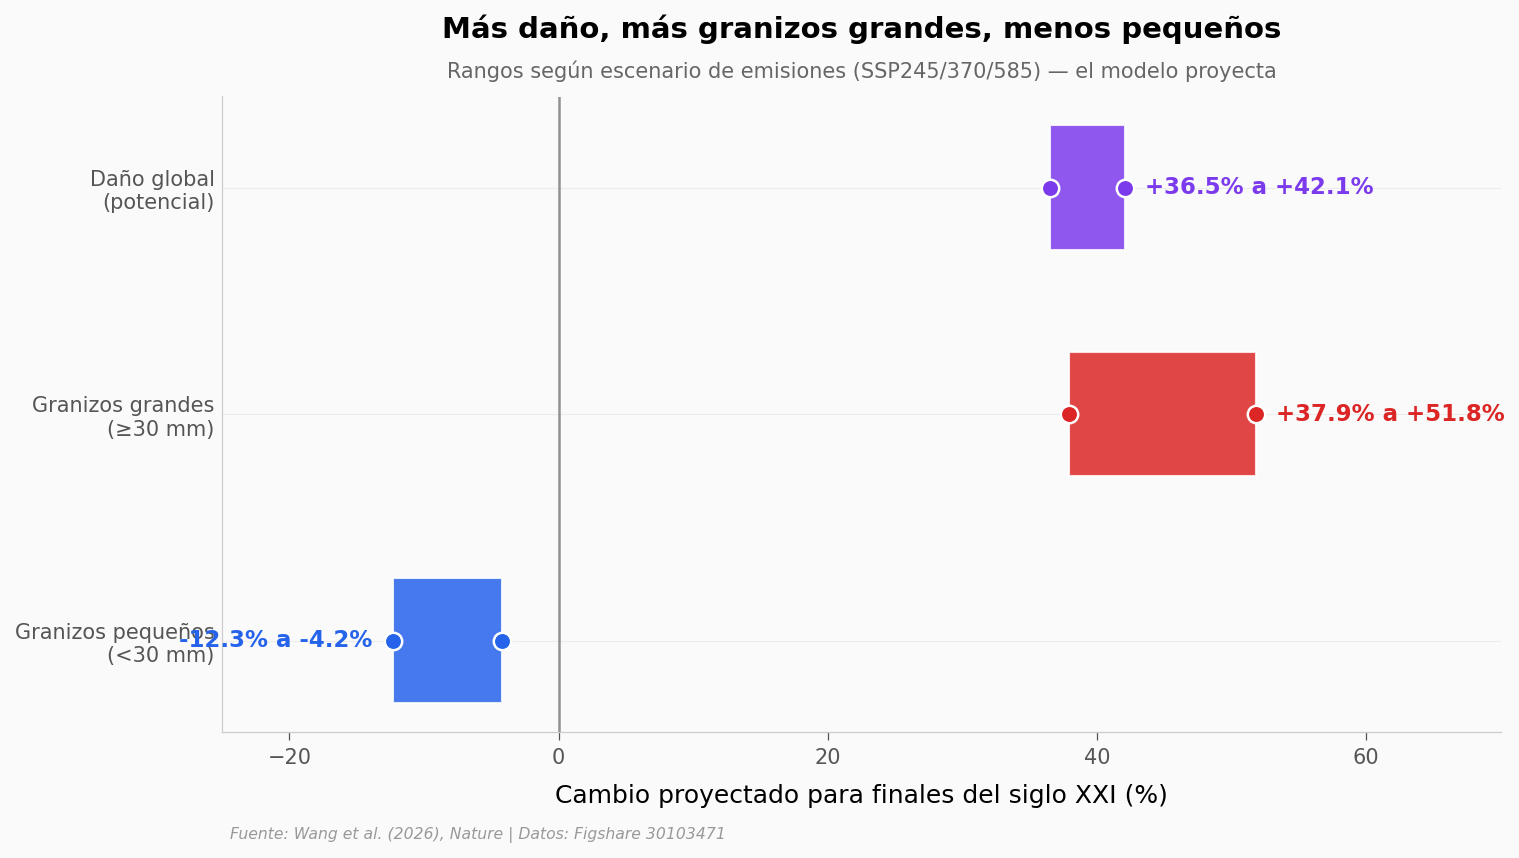

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

# Construir los rangos del paper para finales del s. XXI
metricas = [
    ('Daño global\n(potencial)',          36.5,  42.1, COLOR_PROYECCION),
    ('Granizos grandes\n(≥30 mm)',        37.9,  51.8, COLOR_SIM),
    ('Granizos pequeños\n(<30 mm)',       -12.3, -4.2, COLOR_OBS),
]

y_pos = np.arange(len(metricas))
for i, (label, vmin, vmax, color) in enumerate(metricas):
    # Barra horizontal del rango
    ax.barh(i, vmax - vmin, left=vmin, color=color, alpha=0.85,
            edgecolor='white', linewidth=1, height=0.55, zorder=5)
    # Marcadores en los extremos
    ax.scatter([vmin, vmax], [i, i], color=color, s=70, zorder=6,
               edgecolors='white', linewidths=1.2)
    # Etiqueta de valores
    if vmin >= 0:
        ax.text(vmax + 1.5, i, f'+{vmin:.1f}% a +{vmax:.1f}%',
                fontsize=11, color=color, fontweight='bold', va='center')
    else:
        ax.text(vmin - 1.5, i, f'{vmin:.1f}% a {vmax:.1f}%',
                fontsize=11, color=color, fontweight='bold', va='center', ha='right')

# Línea cero
ax.axvline(x=0, color='#666666', linewidth=1.2, alpha=0.7, zorder=2)

ax.set_yticks(y_pos)
ax.set_yticklabels([m[0] for m in metricas], fontsize=10)
ax.set_xlabel('Cambio proyectado para finales del siglo XXI (%)')
ax.set_xlim(-25, 70)
ax.set_title('Más daño, más granizos grandes, menos pequeños',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Rangos según escenario de emisiones (SSP245/370/585) — el modelo proyecta',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.invert_yaxis()  # primera métrica arriba

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_proyecciones_late21c.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| El modelo proyecta entre 36,5% y 42,1% más daño global por granizo para finales del s. XXI | ✅ | Rango del abstract, según escenario de emisiones SSP245/370/585 |
| Los granizos ≥30 mm aumentan entre 37,9% y 51,8% de frecuencia | ✅ | Rango del abstract — preservar como rango, no colapsar |
| Los granizos <30 mm bajan entre 4,2% y 12,3% | ✅ | Rango del abstract |
| El modelo captura bien las observaciones US (2010-2020) | ✅ | Ratio simulado/observado = 1,20 (recalculado desde el histograma agregado) sobre n=9.462 obs vs n=4.103 sim |
| La sobreestimación 2,5x en China NO es error del modelo | ⚠️ | Lectura del paper apoyada por los datos: entre los 70s y 90s los eventos reportados se cuadruplican y el diámetro medio cae 40% — sesgo de densificación, no clima |
| Latitudes medias-altas verán más daño; trópicos verán menos | ⚠️ | El paper lo enmarca como resultado regional del modelo (atribución a calentamiento fuerte + humedecimiento débil en latitudes medias). No verificable desde los CSVs reproducibles. |

> **Limitaciones del notebook:**
> - Los datos brutos de las proyecciones futuras (>5 GB de NetCDF) no son descargables; las cifras del abstract son la fuente autoritativa para el panel de proyecciones.
> - El muestreo de 3.996 entornos convectivos (SOM5) no es una densidad espacial real de tormentas — está sesgado a baja latitud porque allí hay mayor diversidad de entornos a clasificar.
> - El histograma US tiene irregularidades (picos en bins de 25-30, 40-45, 50-55 mm) propias del redondeo en reportes humanos.

## Ahora tú

1. **¿Qué fracción de los entornos históricos tiene MUCAPE por encima del umbral de tormenta severa (2.500 J/kg)?**
   *Pista:* `entornos[entornos.mucape_jkg > 2500].shape[0] / len(entornos)`

2. **¿Cómo se ve la distribución de altura de fusión (`hmelt_m`) entre los entornos tropicales (|lat|<23,5°) vs las latitudes medias?**
   *Pista:* dos `hist()` o `boxplot()` superpuestos.

3. **El modelo proyecta más granizos grandes y menos pequeños. ¿Cuál es la diferencia absoluta esperada en el _número total_ de eventos si asumes que los granizos grandes representaban 12% del total histórico?**
   *Pista:* combinación lineal de los porcentajes del CSV `proy`.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta: ¿en qué bandas de latitud abundan los entornos con MUCAPE extrema (>5.000 J/kg)?

mucape_extremo = entornos[entornos.mucape_jkg > 5000].copy()

# Bandas de latitud cada 15°
bandas = pd.cut(
    mucape_extremo.lat.abs(),
    bins=[0, 15, 30, 45, 60, 90],
    labels=['0-15° (ecuatorial)', '15-30° (tropical)',
            '30-45° (subtropical)', '45-60° (latitud media)', '60-90° (alta)']
)
conteo = bandas.value_counts().sort_index()

print('Entornos con MUCAPE > 5.000 J/kg por banda de latitud:')
for banda, n in conteo.items():
    pct = n / len(mucape_extremo) * 100
    print(f'  {banda:30s}  {n:4d}  ({pct:4.1f}%)')

print(f'\nTotal entornos extremos: {len(mucape_extremo):,} de {len(entornos):,} ({len(mucape_extremo)/len(entornos)*100:.1f}%)')

Entornos con MUCAPE > 5.000 J/kg por banda de latitud:
  0-15° (ecuatorial)                40  (71.4%)
  15-30° (tropical)                  7  (12.5%)
  30-45° (subtropical)               6  (10.7%)
  45-60° (latitud media)             0  ( 0.0%)
  60-90° (alta)                      0  ( 0.0%)

Total entornos extremos: 56 de 3,996 (1.4%)


## Fuentes

**Paper**: [Rising global hail damage potential in a warming world](https://doi.org/10.1038/s41586-026-10543-2)  
*Nature, 2026-05-27*

**Datos**: [Data for Global hailstone under historical and future scenarios](https://doi.org/10.6084/m9.figshare.30103471.v3)  
*Figshare*

**Material adicional**:  
- [Code for Global hailstone under historical and future scenarios](https://doi.org/10.6084/m9.figshare.30103474.v2) — *Figshare*
- [Raw hailstone growth trajectories (HIST + SSP245/370/585, 4 records)](https://doi.org/10.5281/zenodo.18152366) — *Zenodo*

*18 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook generado por [Ciencia a Mordiscos](https://cienciaamordiscos.com) — [@CienciaAMordiscos](https://youtube.com/@CienciaAMordiscos).*
*Código y datos en [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab).*